In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt
import os

## Data preparation

In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 20

BASE_PATH = "/kaggle/input/lcc-fasd/LCC_FASD"
TRAIN_DIR = os.path.join(BASE_PATH, "LCC_FASD_training")
VAL_DIR =   os.path.join(BASE_PATH, "LCC_FASD_development")

In [6]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary' # 0=Real, 1=Spoof 
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

class_names = train_ds.class_names
print("Class names:", class_names)

Found 8299 files belonging to 2 classes.
Found 2948 files belonging to 2 classes.
Class names: ['real', 'spoof']


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Data augmentation

In [8]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
])

## Load MobileNetV2

In [9]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False, 
    weights='imagenet'
)
base_model.trainable = False # Freeze base for first pass

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [10]:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/20


I0000 00:00:1763568017.923087     117 cuda_dnn.cc:529] Loaded cuDNN version 90300


260/260 ━━━━━━━━━━━━━━━━━━━━ 89s 119ms/step - accuracy: 0.7544 - loss: 0.5470 - val_accuracy: 0.8626 - val_loss: 0.4096
Epoch 2/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 18s 68ms/step - accuracy: 0.8488 - loss: 0.4237 - val_accuracy: 0.8626 - val_loss: 0.3789
Epoch 3/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 18s 70ms/step - accuracy: 0.8455 - loss: 0.3935 - val_accuracy: 0.8630 - val_loss: 0.3586
Epoch 4/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - accuracy: 0.8524 - loss: 0.3598 - val_accuracy: 0.8687 - val_loss: 0.3483
Epoch 5/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 19s 73ms/step - accuracy: 0.8535 - loss: 0.3472 - val_accuracy: 0.8674 - val_loss: 0.3335
Epoch 6/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 19s 74ms/step - accuracy: 0.8652 - loss: 0.3290 - val_accuracy: 0.8697 - val_loss: 0.3298
Epoch 7/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 19s 73ms/step - accuracy: 0.8665 - loss: 0.3171 - val_accuracy: 0.8660 - val_loss: 0.3246
Epoch 8/20
260/260 ━━━━━━━━━━━━━━━━━━━━ 19s 72ms/step - accuracy: 0.8657 - loss: 0.3139 - val_accura

## Evaluate the model

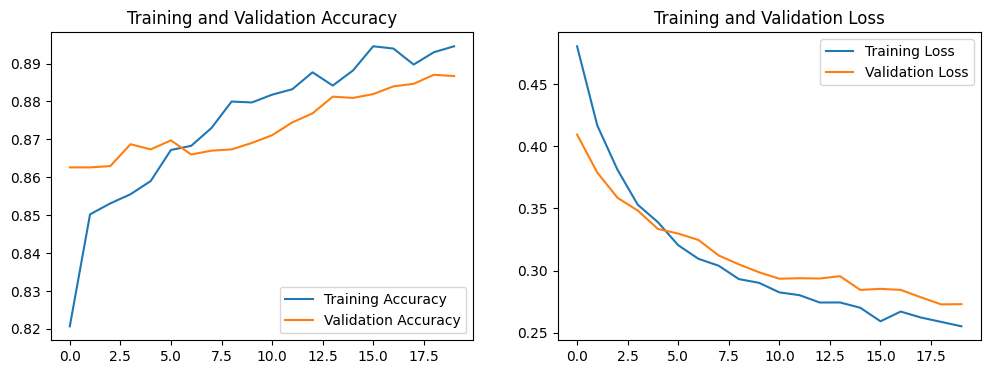

Found 2948 files belonging to 2 classes.

Class Mapping: ['real', 'spoof']

Running Predictions... (This may take a moment)


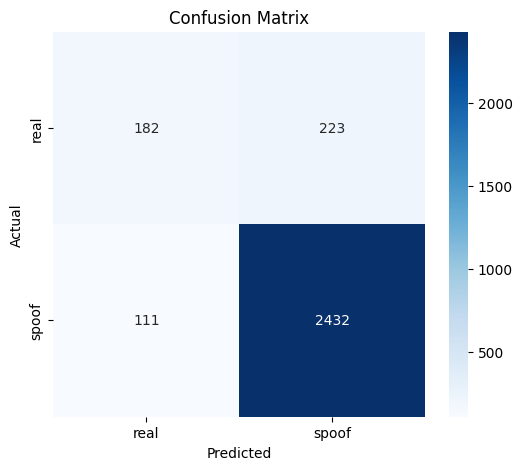


--- Classification Report ---
              precision    recall  f1-score   support

        real       0.62      0.45      0.52       405
       spoof       0.92      0.96      0.94      2543

    accuracy                           0.89      2948
   macro avg       0.77      0.70      0.73      2948
weighted avg       0.88      0.89      0.88      2948



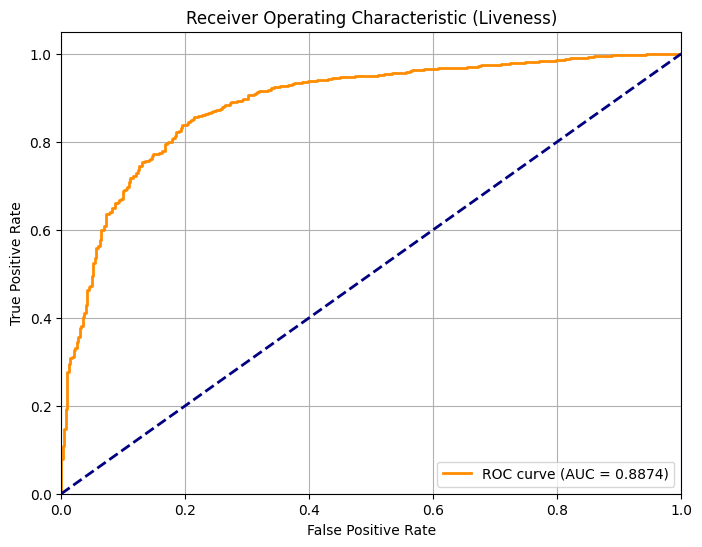

Final Liveness AUC: 0.8874


In [14]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import seaborn as sns

# Plot Training History
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# Prepare Evaluation Data
eval_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    shuffle=False 
)

class_names = eval_ds.class_names
print(f"\nClass Mapping: {class_names}")

# Generate Predictions
print("\nRunning Predictions... (This may take a moment)")

# Extract labels and predictions
y_true = []
y_pred_probs = []

for images, labels in eval_ds:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true).flatten()
y_pred_probs = np.array(y_pred_probs).flatten()

# Convert probabilities to binary class (0 or 1) based on 0.5 threshold
y_pred_binary = (y_pred_probs > 0.5).astype(int)

# Confusion Matrix ---
cm = confusion_matrix(y_true, y_pred_binary)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred_binary, target_names=class_names))

# ROC Curve & AUC
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (Liveness)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print(f"Final Liveness AUC: {roc_auc:.4f}")

## Download the model

In [15]:
model_name = 'liveness_model.keras'
model.save(model_name)
print(f"\nModel saved as {model_name}")

# Create download link
from IPython.display import FileLink
FileLink(model_name)


Model saved as liveness_model.keras


/kaggle/working/liveness_model.keras